# Notebook 2 — Visual Design Standards
**Luis Mitrovic Balbontín Archive**

Defines and exports the canonical color reference panel used across all figures in the thesis.
Four palettes are established: semantic (NER entity types), functional (model evaluation and
corpus language), network node type, epistolary period, and correspondence language.
Running this notebook regenerates `fig_color_reference_v3.png`, the authoritative color
reference for the project.

**Output:** `figures/fig_color_reference_v3.png`

In [2]:
from pathlib import Path

BASE    = Path.cwd().parent
FIGURES = BASE / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"FIGURES: {FIGURES}")

FIGURES: C:\Users\felip\mitrovic-archive\figures


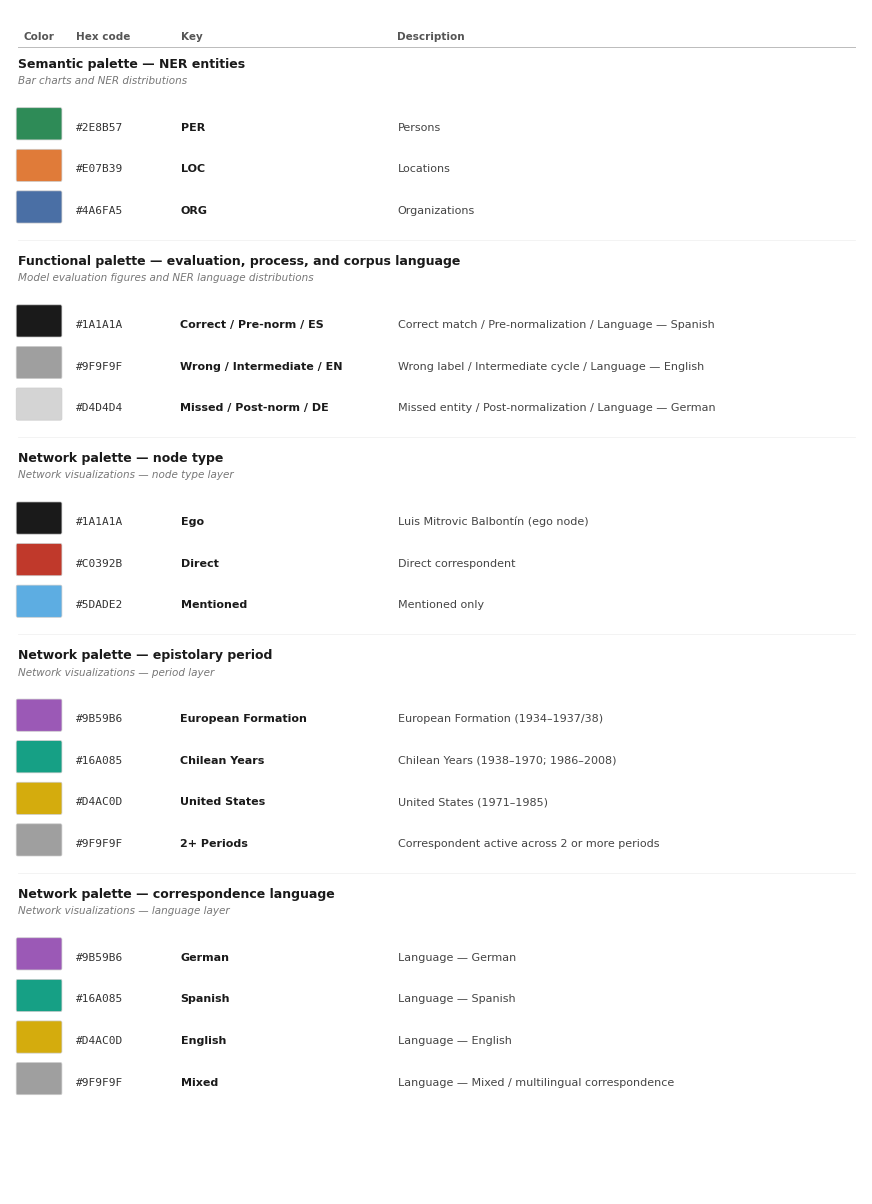

Color reference table v3 exported.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color systems definition 
color_systems = [
    {
        "title": "Semantic palette — NER entities",
        "subtitle": "Bar charts and NER distributions",
        "entries": [
            ("#2E8B57", "PER",  "Persons"),
            ("#E07B39", "LOC",  "Locations"),
            ("#4A6FA5", "ORG",  "Organizations"),
        ]
    },
    {
        "title": "Functional palette — evaluation, process, and corpus language",
        "subtitle": "Model evaluation figures and NER language distributions",
        "entries": [
            ("#1a1a1a", "Correct / Pre-norm / ES",   "Correct match / Pre-normalization / Language — Spanish"),
            ("#9F9F9F", "Wrong / Intermediate / EN", "Wrong label / Intermediate cycle / Language — English"),
            ("#d4d4d4", "Missed / Post-norm / DE",   "Missed entity / Post-normalization / Language — German"),
        ]
    },
    {
        "title": "Network palette — node type",
        "subtitle": "Network visualizations — node type layer",
        "entries": [
            ("#1A1A1A", "Ego",       "Luis Mitrovic Balbontín (ego node)"),
            ("#C0392B", "Direct",    "Direct correspondent"),
            ("#5DADE2", "Mentioned", "Mentioned only"),
        ]
    },
    {
        "title": "Network palette — epistolary period",
        "subtitle": "Network visualizations — period layer",
        "entries": [
            ("#9B59B6", "European Formation",    "European Formation (1934–1937/38)"),
            ("#16A085", "Chilean Years",         "Chilean Years (1938–1970; 1986–2008)"),
            ("#D4AC0D", "United States",         "United States (1971–1985)"),
            ("#9F9F9F", "2+ Periods",            "Correspondent active across 2 or more periods"),
        ]
    },
    {
        "title": "Network palette — correspondence language",
        "subtitle": "Network visualizations — language layer",
        "entries": [
            ("#9B59B6", "German",  "Language — German"),
            ("#16A085", "Spanish", "Language — Spanish"),
            ("#D4AC0D", "English", "Language — English"),
            ("#9F9F9F", "Mixed",   "Language — Mixed / multilingual correspondence"),
        ]
    },
]

# Layout constants 
ROW_H      = 0.54
SEC_HEAD_H = 0.82
SEC_GAP    = 0.30
SWATCH_W   = 0.55
LEFT_PAD   = 0.10
FIG_W      = 11.0

# Column x positions
X_HEX  = LEFT_PAD + SWATCH_W + 0.20
X_KEY  = LEFT_PAD + SWATCH_W + 1.55
X_DESC = LEFT_PAD + SWATCH_W + 4.35  

# Calculate total figure height
total_rows = sum(len(s["entries"]) for s in color_systems)
total_secs = len(color_systems)
fig_h = (total_rows * ROW_H) + (total_secs * SEC_HEAD_H) + \
        (total_secs * SEC_GAP) + 0.60

fig, ax = plt.subplots(figsize=(FIG_W, fig_h))
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, fig_h)
ax.axis("off")
fig.patch.set_facecolor("white")

# Column headers 
y_cursor = fig_h - 0.28
for x, label, ha in [
    (LEFT_PAD + SWATCH_W / 2, "Color",       "center"),
    (X_HEX,                   "Hex code",    "left"),
    (X_KEY,                   "Key",         "left"),
    (X_DESC,                  "Description", "left"),
]:
    ax.text(x, y_cursor, label,
            fontsize=7.5, fontweight="bold", color="#555555",
            ha=ha, va="top")

y_cursor -= 0.20
ax.axhline(y_cursor,
           xmin=LEFT_PAD / FIG_W,
           xmax=(FIG_W - LEFT_PAD) / FIG_W,
           color="#bbbbbb", linewidth=0.7)
y_cursor -= 0.14

# Draw sections 
for s_idx, sec in enumerate(color_systems):

    # Section title
    ax.text(LEFT_PAD, y_cursor,
            sec["title"],
            fontsize=9, fontweight="bold", color="#1a1a1a",
            ha="left", va="top")
    y_cursor -= 0.24

    # Section subtitle
    ax.text(LEFT_PAD, y_cursor,
            sec["subtitle"],
            fontsize=7.5, color="#777777", style="italic",
            ha="left", va="top")
    y_cursor -= 0.40

    # Entry rows
    for hex_color, key, description in sec["entries"]:

        row_mid = y_cursor - ROW_H * 0.50

        # Color swatch
        swatch = mpatches.FancyBboxPatch(
            (LEFT_PAD, y_cursor - ROW_H * 0.76),
            SWATCH_W, ROW_H * 0.70,
            boxstyle="round,pad=0.02",
            facecolor=hex_color,
            edgecolor="#cccccc",
            linewidth=0.5
        )
        ax.add_patch(swatch)

        # Hex code
        ax.text(X_HEX, row_mid,
                hex_color.upper(),
                fontsize=8, fontfamily="monospace",
                color="#333333", ha="left", va="center")

        # Key
        ax.text(X_KEY, row_mid,
                key,
                fontsize=8, fontweight="bold",
                color="#1a1a1a", ha="left", va="center")

        # Description
        ax.text(X_DESC, row_mid,
                description,
                fontsize=8, color="#444444",
                ha="left", va="center")

        y_cursor -= ROW_H

    # Section separator (except last)
    if s_idx < len(color_systems) - 1:
        y_cursor -= SEC_GAP * 0.35
        ax.axhline(y_cursor,
                   xmin=LEFT_PAD / FIG_W,
                   xmax=(FIG_W - LEFT_PAD) / FIG_W,
                   color="#eeeeee", linewidth=0.5)
        y_cursor -= SEC_GAP * 0.65

# Export 
plt.savefig(FIGURES / "fig_color_reference_v3.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.savefig(FIGURES / "fig_color_reference_v3.pdf", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Color reference table v3 exported.")